# POC : Appel à un modèle Hugging Face pour la segmentation d'images

Ce notebook présente un POC (Proof Of Concept) visant à valider l'utilisation d'un modèle d'IA pré-entraîné disponible sur Hugging Face pour réaliser de la segmentation d'images.
Cette segmentation consiste dans notre cas à identifier et différencier les différents vêtements portés sur une image : t-shirt, pantalon, chemise, etc.
Nous interrogerons le modèle d'IA via une API d'inférence et exploiterons un jeu de données afin de visualiser et analyser les résultats retournés.

Pour parvenir à cet objectif, nous aborderons les étapes suivantes : 
- Configuration de l'environnement
- Appel du modèle d'IA via l'API d'inférence
- Développement du script de segmentation
- Visualisation et analyse des résultats
- Réflexion sur la mise à l'échelle de la solution

## 

## Configuration de l'environnement

### Bibliothèques Python

Nous importons les bibliothèques Python nécessaires.

Les bibliothèques standard Python : 
- `os` => manipulation de dossiers et fichiers.
- `base64` => encodage et décodage de données binaires en Base64.
- `io` => manipulation de flux de données en mémoire.
- `time` => gestion des temporisations.

Les bibliothèques tierces : 
- `python-dotenv` => gestion des paires clé/valeur du fichier `.env`.
- `requests` => envoi des requêtes HTTP.
- `Pillow` => manipulation d'images
- `numpy` => manipulation de tableaux
- `matplotlib` => construction de visualisations
- `tqdm` => affichage d'une barre de progression

In [2]:
import os
import base64
import io
import time
from dotenv import load_dotenv
import requests
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from tqdm.notebook import tqdm

### Paramètres de configuration et variable d'environnement

Nous définissons les paramètres nécessaires au traitement : 
- `IMAGE_DIR` => chemin du dossier contenant les images.
- `MAX_IMAGES` => nombre maximum d'images à traiter.
- `API_TOKEN` => jeton d'API Hugging Face récupéré depuis la variable d'environnement `HUGGING_FACE_TOKEN`.

> **Le jeton d'API doit rester secret !**
> 
> Il est stocké dans le fichier `.env`.

In [3]:
# Variables concernant les images à traiter
IMAGE_DIR = "./data/images"
MAX_IMAGES = 3

# Création de la variable du token d'API depuis le fichier `.env`
load_dotenv()
API_TOKEN = os.getenv('HUGGING_FACE_TOKEN')

# Vérification de l'existence du dossier d'images
if os.path.exists(IMAGE_DIR):
    print(f"Dossier '{IMAGE_DIR}' existant.")
else:
    os.makedirs(IMAGE_DIR)
    print(f"Dossier '{IMAGE_DIR}' créé, vous pouvez y ajouter des images .jpg ou .png.")

# Vérification de la présence du token d'API
if API_TOKEN:
    print("Token d'API chargé avec succès.")
else:
    raise ValueError("La variable du token d'API n'est pas définie")

Dossier './data/images' existant.
Token d'API chargé avec succès.


## Appel du model d'IA via l'API d'inférence

Nous utilisons un modèle d'IA hébergé sur Hugging Face.
Pour l'interroger, nous utilisons une API d'inférence.

Afin d'effectuer les appels au modèle, nous définissons les variables suivantes : 

- `API_URL` => URL de l'endpoint d'inférence du modèle
- `headers` => En-têtes HTTP utilisés pour pour l'authentification
- `image_paths` => Liste des chemins des images à traiter

Le premier modèle que nous utilisons est `sayeed99/segformer_b3_clothes`, spécialisé dans la segmentation de vêtements.

In [4]:
API_URL = "https://router.huggingface.co/hf-inference/models/sayeed99/segformer_b3_clothes"

headers = {
    "Authorization": f"Bearer {API_TOKEN}"
}

image_paths = []

# Pour chaque nom de fichier du dossier IMAGE_DIR
for filename in os.listdir(IMAGE_DIR):
    # Vérification du type de fichier
    if filename.lower().endswith((".jpg", ".png")):
        # Création du chemin de l'image
        image_path = os.path.join(IMAGE_DIR, filename)
        # Ajout à la liste
        image_paths.append(image_path)

# Vérification de la présence de chemins d'images dans la liste
if not image_paths:
    print(f"Aucune image trouvée dans '{IMAGE_DIR}'. Veuillez y ajouter des images .jpg ou .png.")
else:
    print(f"{len(image_paths)} image(s) à traiter : {image_paths}")


50 image(s) à traiter : ['./data/images/image_16.png', './data/images/image_45.png', './data/images/image_3.png', './data/images/image_9.png', './data/images/image_37.png', './data/images/image_41.png', './data/images/image_15.png', './data/images/image_40.png', './data/images/image_35.png', './data/images/image_1.png', './data/images/image_24.png', './data/images/image_22.png', './data/images/image_7.png', './data/images/image_17.png', './data/images/image_12.png', './data/images/image_5.png', './data/images/image_19.png', './data/images/image_21.png', './data/images/image_25.png', './data/images/image_28.png', './data/images/image_0.png', './data/images/image_47.png', './data/images/image_30.png', './data/images/image_39.png', './data/images/image_32.png', './data/images/image_11.png', './data/images/image_26.png', './data/images/image_31.png', './data/images/image_8.png', './data/images/image_4.png', './data/images/image_2.png', './data/images/image_46.png', './data/images/image_49.

## Développement du script de segmentation

### Fonctions utilitaires pour le traitement des masques

Le modèle `sayeed99/segformer_b3_clothes` retourne plusieurs masques de segmentation, chacun associé à une classe détectée : cheveux, pantalon, robe, etc.

Ces masques sont encodés en Base64. Afin de les exploiter et de construire le masque de segmentation final, nous utilisons plusieurs fonctions utilitaires :

- `CLASS_MAPPING` => associe chaque classe détectable à un identifiant numérique.
- `get_image_dimensions()` => récupère les dimensions de l'image d'origine.
- `decode_base64_mask()` => décode un masque Base64, le convertit en tableau NumPy et l'adapte aux dimensions de l'image.
- `create_masks()` => combine les différents masques retournés par le modèle afin de produire un masque de segmentation final.

In [ ]:
CLASS_MAPPING = {
    "Background": 0,
    "Hat": 1,
    "Hair": 2,
    "Sunglasses": 3,
    "Upper-clothes": 4,
    "Skirt": 5,
    "Pants": 6,
    "Dress": 7,
    "Belt": 8,
    "Left-shoe": 9,
    "Right-shoe": 10,
    "Face": 11,
    "Left-leg": 12,
    "Right-leg": 13,
    "Left-arm": 14,
    "Right-arm": 15,
    "Bag": 16,
    "Scarf": 17
}

def get_image_dimensions(img_path):
    """
    Get the dimensions of an image.

    Args:
        img_path (str): Path to the image.

    Returns:
        tuple: (width, height) of the image.
    """
    original_image = Image.open(img_path)
    return original_image.size

def decode_base64_mask(base64_string, width, height):
    """
    Decode a base64-encoded mask into a NumPy array.

    Args:
        base64_string (str): Base64-encoded mask.
        width (int): Target width.
        height (int): Target height.

    Returns:
        np.ndarray: Single-channel mask array.
    """
    mask_data = base64.b64decode(base64_string)
    mask_image = Image.open(io.BytesIO(mask_data))
    mask_array = np.array(mask_image)
    if len(mask_array.shape) == 3:
        mask_array = mask_array[:, :, 0]  # Take first channel if RGB
    mask_image = Image.fromarray(mask_array).resize((width, height), Image.NEAREST)
    return np.array(mask_image)

def create_masks(results, width, height):
    """
    Combine multiple class masks into a single segmentation mask.

    Args:
        results (list): List of dictionaries with 'label' and 'mask' keys.
        width (int): Target width.
        height (int): Target height.

    Returns:
        np.ndarray: Combined segmentation mask with class indices.
    """
    combined_mask = np.zeros((height, width), dtype=np.uint8)  # Initialize with Background (0)

    # Process non-Background masks first
    for result in results:
        label = result['label']
        class_id = CLASS_MAPPING.get(label, 0)
        if class_id == 0:  # Skip Background
            continue
        mask_array = decode_base64_mask(result['mask'], width, height)
        combined_mask[mask_array > 0] = class_id

    # Process Background last to ensure it doesn't overwrite other classes unnecessarily
    # (Though the model usually provides non-overlapping masks for distinct classes other than background)
    for result in results:
        if result['label'] == 'Background':
            mask_array = decode_base64_mask(result['mask'], width, height)
            # Apply background only where no other class has been assigned yet
            # This logic might need adjustment based on how the model defines 'Background'
            # For this model, it seems safer to just let non-background overwrite it first.
            # A simple application like this should be fine: if Background mask says pixel is BG, set it to 0.
            # However, a more robust way might be to only set to background if combined_mask is still 0 (initial value)
            combined_mask[mask_array > 0] = 0 # Class ID for Background is 0

    return combined_mask

### Segmentation d'une image

Avant de traiter plusieurs images, nous commençons par tester le processus de segmentation sur une seule image.

Les étapes sont les suivantes :

- Sélectionner la première image de la liste `image_paths`.
- Ouvrir l'image en mode binaire et récupérer son contenu.
- Déterminer son type MIME (`image/jpeg` ou `image/png`).
- Envoyer l'image au modèle avec une requête HTTP `POST`.
- Vérifier que la requête a abouti.
- Récupérer les résultats retournés par l'API au format JSON.
- Construire le masque de segmentation à partir des résultats.

In [6]:
if image_paths:
    single_image_path = image_paths[0]
    print(f"Traitement de l'image : {single_image_path}")

    try:
        # Lecture de l'image en binaire
        # Utilisation du statement with
        with open(single_image_path, "rb") as image_file:
            image_data = image_file.read()

        # Détermination du type de l'image
        if single_image_path.lower().endswith(".jpg"):
            content_type = "image/jpeg"
        elif single_image_path.lower().endswith(".png"):
            content_type = "image/png"

        # Ajout du Content-Type aux headers
        headers["Content-Type"] = content_type

        # Envoi de l'image à l'API d'inférence
        response = requests.post(
            API_URL,
            headers=headers,
            data=image_data
        )

        # Vérification du statut de la réponse et levée d'une exception en cas d'erreur HTTP
        response.raise_for_status()

        # Récupération des résultats retournés par l'API au format JSON
        results = response.json()

        # Récupération des dimensions de l'image
        width, height = get_image_dimensions(single_image_path)

        # Création du masque de segmentation
        segmentation_mask = create_masks(results, width, height)

        # Vérification des dimensions du masque obtenu
        print(f"Dimensions du masque : {segmentation_mask.shape}")

    except Exception as e:
        print(f"Une erreur est survenue : {e}")
else:
    print("Aucune image à traiter.")

Traitement de l'image : ./data/images/image_16.png
Dimensions du masque : (600, 400)


### Segmentation de plusieurs images

Après avoir validé le processus de segmentation sur une image, nous pouvons l'appliquer à plusieurs images.

Pour cela, nous créons une fonction `segment_images_batch()` qui parcourt la liste des images à traiter, effectue la segmentation de chacune d'elles et stocke les masques obtenus dans une liste.

Une barre de progression `tqdm` permet de suivre l'avancement du traitement.

In [7]:
def segment_images_batch(list_of_image_paths):
    # Initialisation de la liste des masques de segmentation
    batch_segmentations = []

    # Traitement de chaque image de la liste
    # tqdm enveloppe l'itérable pour suivre sa progression
    for image_path in tqdm(list_of_image_paths):

        try:
            # Lecture de l'image en binaire
            with open(image_path, "rb") as image_file:
                image_data = image_file.read()

            # Détermination du type de l'image
            if image_path.lower().endswith(".jpg"):
                content_type = "image/jpeg"
            elif image_path.lower().endswith(".png"):
                content_type = "image/png"

            # Ajout du Content-Type aux headers
            headers["Content-Type"] = content_type

            # Envoi de l'image à l'API d'inférence
            response = requests.post(
                API_URL,
                headers=headers,
                data=image_data
            )

            # Vérification du statut de la réponse et levée d'une exception en cas d'erreur HTTP
            response.raise_for_status()

            # Récupération des résultats retournés par l'API au format JSON
            results = response.json()

            # Récupération des dimensions de l'image
            width, height = get_image_dimensions(image_path)

            # Création du masque de segmentation
            segmentation_mask = create_masks(results, width, height)

            # Ajout du masque à la liste
            batch_segmentations.append(segmentation_mask)

        except Exception as e:
            # En cas d'erreur de traitement d'une image:
            # - On lève une exception
            # - On ajoute 'None' à la liste afin de ne pas perdre la correspondance images/masques
            print(f"Erreur lors du traitement de '{image_path}' : {e}")
            batch_segmentations.append(None)

        # Pause entre deux appels à l'API
        time.sleep(1)

    return batch_segmentations

# Limitation du nombre d'images à traiter
images_to_process = image_paths[:MAX_IMAGES]

# Segmentation des images
if images_to_process:
    print(f"Traitement de {len(images_to_process)} image(s) en batch...")

    batch_seg_results = segment_images_batch(images_to_process)

    print("Traitement en batch terminé.")
else:
    batch_seg_results = []
    print("Aucune image à traiter en batch.")

Traitement de 3 image(s) en batch...


  0%|          | 0/3 [00:00<?, ?it/s]

Traitement en batch terminé.


## Visualisation et analyse de résultats

### Affichage des résultats

Afin de comparer les résultats de segmentation, nous affichons chaque image originale avec le masque de segmentation correspondant.

Pour cela, nous créons une fonction `display_segmented_images_batch()` qui utilise Matplotlib pour afficher les images et leurs masques côte à côte.

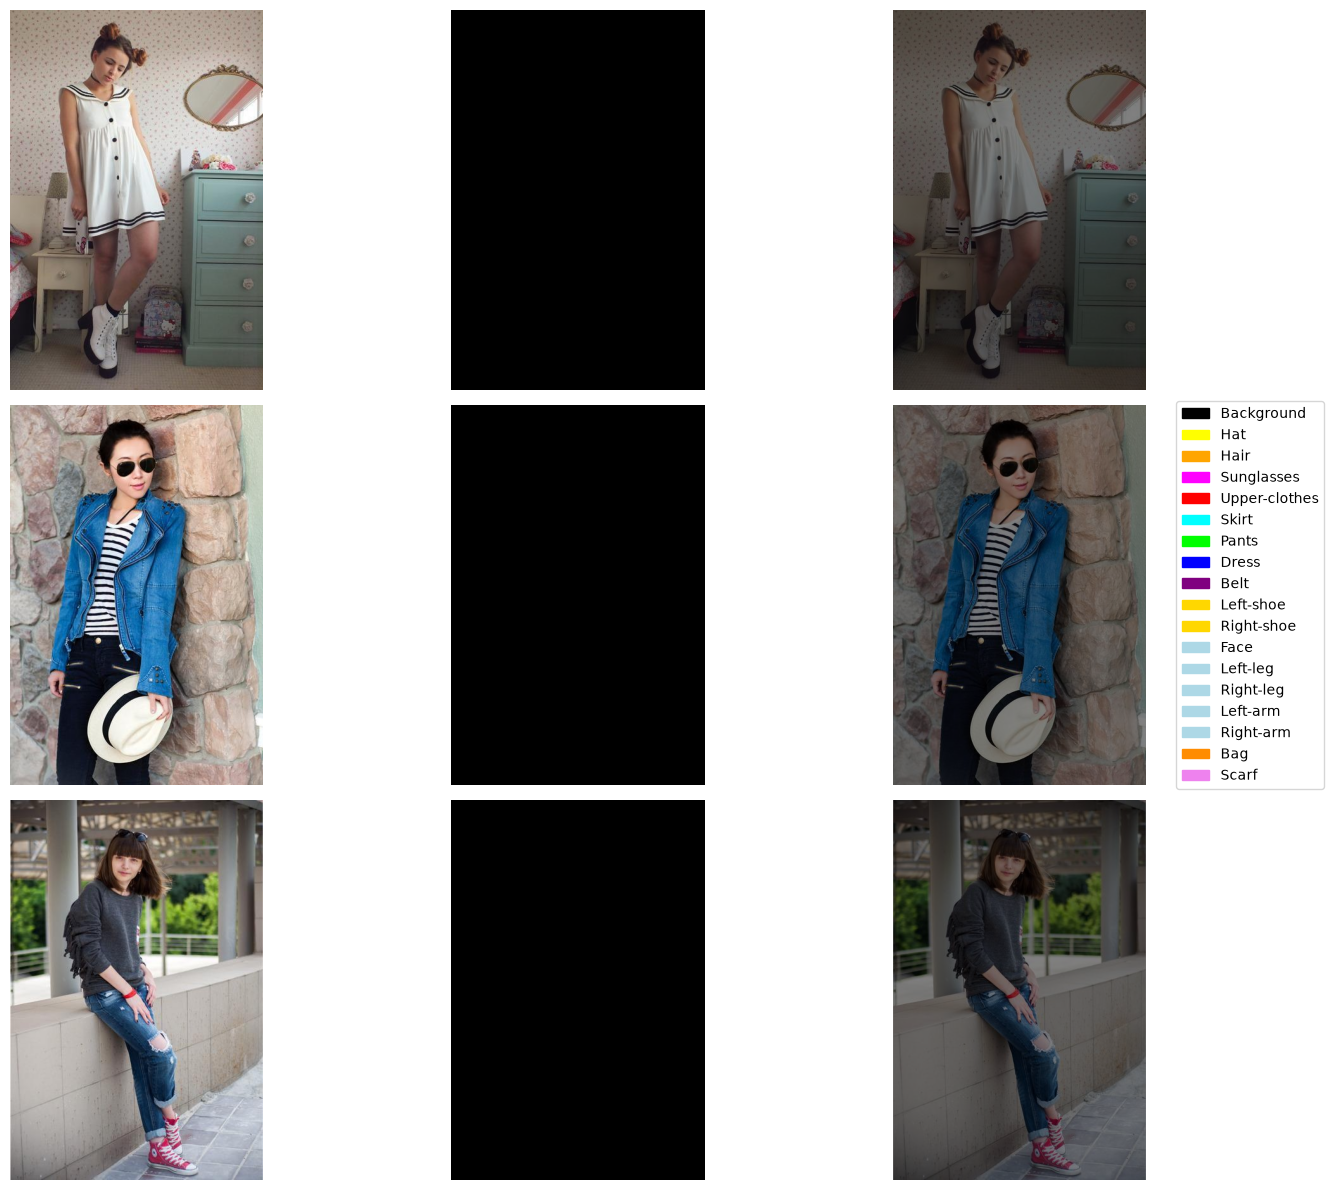

In [9]:
# Association d'une couleur à chaque classe de segmentation
CLASS_COLORS = {
    "Background": "black",
    "Hat": "yellow",
    "Hair": "orange",
    "Sunglasses": "magenta",
    "Upper-clothes": "red",
    "Skirt": "cyan",
    "Pants": "lime",
    "Dress": "blue",
    "Belt": "purple",
    "Left-shoe": "gold",
    "Right-shoe": "gold",
    "Face": "lightblue",
    "Left-leg": "lightblue",
    "Right-leg": "lightblue",
    "Left-arm": "lightblue",
    "Right-arm": "lightblue",
    "Bag": "darkorange",
    "Scarf": "violet"
}

# Création de la palette de couleurs à partir des couleurs des classes
class_cmap = ListedColormap(list(CLASS_COLORS.values()))

# Fonction d'affichage des images et de leurs résultats de segmentation
def display_segmented_images_batch(original_image_paths, segmentation_masks):
    """
    Affiche les images originales et leurs masques segmentés.

    Args:
        original_image_paths (list): Liste des chemins des images originales.
        segmentation_masks (list): Liste des masques de segmentation.
    """

    # Récupération du nombre d'images à afficher
    num_images = len(original_image_paths)

    # Création de la grille d'affichage
    fig, axes = plt.subplots(num_images, 3, figsize=(15, num_images * 4))

    # Création des éléments de la légende
    legend_elements = []

    for class_name, color in CLASS_COLORS.items():
        legend_elements.append(
            Patch(color=color, label=class_name)
        )

    # Création des paramètres d'affichage des masques
    mask_display_params = {
        "cmap": class_cmap,
        "vmin": 0,
        "vmax": len(CLASS_MAPPING) - 1
    }

    # Affichage de chaque image et de son masque
    for i in range(num_images):
        # Ouverture de l'image originale
        original_image = Image.open(original_image_paths[i])

        # Affichage de l'image originale
        axes[i, 0].imshow(original_image)

        # Affichage du masque de segmentation s'il existe
        if segmentation_masks[i] is not None:
            axes[i, 1].imshow(
                segmentation_masks[i],
                **mask_display_params
            )

            # Superposition du masque sur l'image originale
            axes[i, 2].imshow(original_image)
            axes[i, 2].imshow(
                segmentation_masks[i],
                **mask_display_params,
                alpha=0.5
            )

        # Suppression des axes
        axes[i, 0].axis("off")
        axes[i, 1].axis("off")
        axes[i, 2].axis("off")

    # Ajustement de l'espacement
    fig.tight_layout()

    # Affichage de la légende
    fig.legend(
        handles=legend_elements,
        loc="center right"
    )

    # Affichage de la figure
    plt.show()

# Afficher les résultats du batch
if batch_seg_results:
    display_segmented_images_batch(images_to_process, batch_seg_results)
else:
    print("Aucun résultat de segmentation à afficher.")

### Analyse de résultats

Les résultats obtenus montrent que le modèle est capable d'identifier et de segmenter différentes parties des vêtements et du corps présentes sur les images.

La superposition des masques sur les images originales permet de vérifier visuellement la cohérence des segmentations et de repérer plus facilement les éventuelles erreurs de classification.

Les résultats peuvent varier selon les images, notamment en fonction de la position du sujet, des vêtements portés ou de la complexité de l'arrière-plan.